Task 1. 
DNA / Protein Sequence analysis
- Download from NCBI or Uniport
- Perform BLAST analysis to find homologous sequence + Document results (similarity, identity, alignment score) 2-3 pages

1. Installation
2. Download sequences from Uniprot and NCBI
3. Working with FASTQ and FASTA files 
4. Running BLAST
5. Parsing results --> Similarity, identity and scores
6. Full report 

In [1]:
# installation 
%pip install -q biopython requests pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Importing 
import os
import re
import time
from datetime import datetime
from types import SimpleNamespace
import concurrent.futures as futures

import requests
import pandas as pd
import matplotlib.pyplot as plt

from Bio import Entrez, SeqIO
from Bio.Blast import NCBIWWW, NCBIXML
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

# configuration
Entrez.email = "ncbi_account@email.com"

_api_key = os.environ.get("NCBI_API_KEY")
if _api_key:
    Entrez.api_key = _api_key

OUTPUT_DIR = "blast_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

pd.set_option("display.max_colwidth", 75)

In [3]:
# Downloading NCBI

def download_from_ncbi(accession, db="protein", rettype="fasta",
                       retmode="text", filename=None):

    if filename is None:
        ext = "fasta" if rettype == "fasta" else "gb"
        filename = os.path.join(OUTPUT_DIR, accession.replace(".", "_") + "." + ext)

    print("Fetching %s from NCBI db='%s' ..." % (accession, db))

    with Entrez.efetch(db=db, id=accession, rettype=rettype, retmode=retmode) as handle:
        data = handle.read()

    if isinstance(data, bytes):                      
        data = data.decode("utf-8")

    if data.lstrip().startswith("<"):                
        raise RuntimeError("NCBI returned an error page — check the accession "
                           "and your e-mail/API key configuration.")

    with open(filename, "w") as f:
        f.write(data)

    print("Saved %s characters to %s" % (format(len(data), ","), filename))
    return filename


In [4]:
# download test protein with accession
ncbi_protein_file = download_from_ncbi(
    accession="NP_000537.3",
    db="protein",
    rettype="fasta",
    filename=os.path.join(OUTPUT_DIR, "TP53_NCBI_protein.fasta"),
)

# download test Gene
ncbi_gene_file = download_from_ncbi(
    accession="NM_007294.4",
    db="nucleotide",
    rettype="fasta",
    filename=os.path.join(OUTPUT_DIR, "BRCA1_NCBI_mRNA.fasta"),
)
for fasta_file in (ncbi_protein_file, ncbi_gene_file):
    record = SeqIO.read(fasta_file, "fasta")

Fetching NP_000537.3 from NCBI db='protein' ...
Saved 465 characters to blast_results/TP53_NCBI_protein.fasta
Fetching NM_007294.4 from NCBI db='nucleotide' ...
Saved 7,281 characters to blast_results/BRCA1_NCBI_mRNA.fasta


In [5]:
# download function for Uniprot
UNIPROT_BASE = "https://rest.uniprot.org"
def download_from_uniprot(accession, file_format="fasta", filename=None):
    
    url = "%s/uniprotkb/%s.%s" % (UNIPROT_BASE, accession, file_format)
    print("GET", url)

    response = requests.get(url, timeout=60)
    response.raise_for_status()          # raise if 4xx / 5xx

    if filename is None:
        filename = os.path.join(OUTPUT_DIR, accession.replace(".", "_") + "." + file_format)

    with open(filename, "w") as f:
        f.write(response.text)

    print("Saved %s characters to %s" % (format(len(response.text), ","), filename))
    return filename


In [6]:
# download test protein from Uniprot
uniprot_file = download_from_uniprot(
    accession="P04637",                                    # TP53_HUMAN
    filename=os.path.join(OUTPUT_DIR, "TP53_UniProt.fasta"),
)

record = SeqIO.read(uniprot_file, "fasta")

GET https://rest.uniprot.org/uniprotkb/P04637.fasta
Saved 490 characters to blast_results/TP53_UniProt.fasta


In [7]:
# quality control 
def gc_content(seq):
    """GC calculator"""
    seq = seq.upper()
    if not seq:
        return 0.0
    return 100.0 * (seq.count("G") + seq.count("C")) / len(seq)


def sequence_stats(path):
  
    def protein_mw_kDa(seq):

        try:
            from Bio.SeqUtils import molecular_weight
            try:
                mw = molecular_weight(seq, seq_type="protein")      
            except TypeError:
                mw = molecular_weight(seq, seq_format="protein")  
            return round(mw / 1000, 1)
        except Exception:
            return None

    rows = []
    for record in SeqIO.parse(path, "fasta"):
        seq = str(record.seq).upper()
        is_protein = bool(set(seq) - set("ACGTUN-"))
        row = {"file": os.path.basename(path), "id": record.id,
               "length": len(seq), "type": "protein" if is_protein else "nucleotide"}
        if is_protein:
            row["MW_kDa"] = protein_mw_kDa(record.seq)
        else:
            row["GC_%"] = round(gc_content(seq), 1)
        rows.append(row)
    return pd.DataFrame(rows)


In [8]:
pd.concat(
    [sequence_stats(f) for f in (ncbi_protein_file, ncbi_gene_file, uniprot_file)],
    ignore_index=True,
)

,file,id,length,type,MW_kDa,GC_%
0,TP53_NCBI_protein.fasta,NP_000537.3,393,protein,43.7,NaN
1,BRCA1_NCBI_mRNA.fasta,NM_007294.4,7088,nucleotide,NaN,41.8
2,TP53_UniProt.fasta,sp|P04637|P53_HUMAN,393,protein,43.7,NaN


In [ ]:
def make_demo_fastq(path):
    reads = [
        ("read1", "ATGCGTACGTTAGCCAGGTAA", [40] * 21),                
        ("read2", "GGCCTTAAGGCATTCGATCGA", [30, 35, 38] + [25] * 18),  
    ]
    records = []
    for name, seq, quality in reads:
        rec = SeqRecord(Seq(seq), id=name, description="synthetic demo read")
        rec.letter_annotations["phred_quality"] = quality   
        records.append(rec)
    SeqIO.write(records, path, "fastq")                     
    return path


fastq_file = make_demo_fastq(os.path.join(OUTPUT_DIR, "demo.fastq"))

for record in SeqIO.parse(fastq_file, "fastq"):
    q = record.letter_annotations["phred_quality"]
    mean_q = sum(q) / len(q)
    # P(error) = 10 ** (-Q/10)  →  convert mean Q back to an accuracy estimate
    accuracy = 100 * (1 - 10 ** (-mean_q / 10))

In [ ]:
# BLAST analysis function 
def _blast_ncbi(sequence, program, database, expect, hits, timeout):

    print("Engine NCBI : submitting %s vs '%s' (E <= %g, max %d hits) ..."
          % (program.upper(), database, expect, hits))
    t0 = time.time()
    pool = futures.ThreadPoolExecutor(max_workers=1)
    try:
        job = pool.submit(NCBIWWW.qblast, program, database, sequence,
                          expect=expect, hitlist_size=hits)
        handle = job.result(timeout=timeout)          # qblast polls internally
        xml_data = handle.read()
        handle.close()
        print("Engine NCBI : finished in %.0f s" % (time.time() - t0))
        return xml_data
    except futures.TimeoutError:

        raise TimeoutError("NCBI queue did not finish within %d s" % timeout)
    finally:
        pool.shutdown(wait=False)                   


EBI_BLAST_URL = "https://www.ebi.ac.uk/Tools/services/rest/ncbiblast"
EBI_DB_MAP = {"swissprot": "uniprotkb_swissprot",   
              "nr": "uniprotkb",                    
              "nt": "em_std"}                       
EBI_EXP_VALUES = [1e-200, 1e-100, 1e-50, 1e-10, 1e-5, 1e-4,
                  1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]
EBI_HIT_VALUES = [5, 10, 20, 50, 100, 150, 200, 250, 500, 750, 1000]
DEFAULT_CONTACT = "anonymous.blast.user@example.com"


def _ebi_expect(value):

    nearest = min(EBI_EXP_VALUES, key=lambda v: abs(v - value))
    text = "%g" % nearest
    m = re.match(r"^(.*e[+-])0(\d)$", text)         
    return m.group(1) + m.group(2) if m else text


def _ebi_hits(value):

    return min(EBI_HIT_VALUES, key=lambda v: (abs(v - value), v))


def _ebi_error_detail(resp):
    m = re.search(r"<description>(.*?)</description>", resp.text, re.S)
    if m:
        return " ".join(m.group(1).split())[:400]
    return " ".join(resp.text.split())[:200] or "(empty response body)"


def _blast_ebi(sequence, program, database, expect, hits, email, max_wait=600):
    database = EBI_DB_MAP.get(database, database)

    contact = email or Entrez.email                  
    if not contact or "@" not in contact or "." not in contact.rsplit("@", 1)[-1]:
        print("Engine EBI  : no usable contact e-mail — using %s"
              " (set email=... or Entrez.email)" % DEFAULT_CONTACT)
        contact = DEFAULT_CONTACT

    hits_ebi = _ebi_hits(hits)
    if hits_ebi != hits:
        print("Engine EBI  : hits %s -> %s (EBI accepts only %s)"
              % (hits, hits_ebi, EBI_HIT_VALUES))

    params = {
        "email"    : contact,
        "program"  : program,
        "stype"    : "protein" if program in ("blastp", "tblastn") else "dna",
        "database" : database,
        "sequence" : sequence.strip().replace("*", ""),
        "exp"      : _ebi_expect(expect),
        "alignments": hits_ebi, "scores": hits_ebi,
        "gapalign" : "true",
    }
    if program == "blastp":
        params["matrix"] = "BLOSUM62"

    print("Engine EBI  : submitting %s vs '%s' ..." % (program.upper(), database))
    t0 = time.time()
    resp = requests.post(EBI_BLAST_URL + "/run", data=params, timeout=60)
    if resp.status_code != 200:

        raise RuntimeError("EBI rejected the submission (HTTP %d): %s"
                           % (resp.status_code, _ebi_error_detail(resp)))
    job_id = resp.text.strip()
    if not job_id:
        raise RuntimeError("EBI service did not return a job id")
    print("Engine EBI  : job id %s" % job_id)

    waited = 0
    while waited < max_wait:                      
        time.sleep(8); waited += 8
        status = requests.get(EBI_BLAST_URL + "/status/" + job_id, timeout=60).text.strip()
        if status in ("COMPLETE", "FINISHED"):
            break
        if status in ("ERROR", "FAILURE", "NOT_FOUND"):
            raise RuntimeError("EBI job ended with status '%s'" % status)
        print("Engine EBI  : %s (%d s elapsed)" % (status, waited))
    else:
        raise TimeoutError("EBI job did not finish within %d s" % max_wait)

    xml = requests.get(EBI_BLAST_URL + "/result/%s/xml" % job_id, timeout=120).text
    if "SequenceSimilaritySearchResult" not in xml[:3000]:
        raise RuntimeError("EBI returned an unexpected XML document")
    print("Engine EBI  : finished in %.0f s" % (time.time() - t0))
    return xml


def run_blast(sequence, program="blastp", database="swissprot", expect=1e-3,
              hits=50, xml_file=None, engine="auto", timeout=240, email=None):

    if xml_file is None:
        xml_file = os.path.join(OUTPUT_DIR, "blast_%s_%s.xml" % (program, database))

    xml_data = None
    if engine in ("ncbi", "auto"):
        try:
            xml_data = _blast_ncbi(sequence, program, database, expect, hits, timeout)
        except Exception as err:
            if engine == "ncbi":
                raise
            print("Engine NCBI : giving up (%s: %s)" % (type(err).__name__, err))

    if xml_data is None:                              # engine="ebi" or auto-fallback
        xml_data = _blast_ebi(sequence, program, database, expect, hits, email)

    with open(xml_file, "w") as f:
        f.write(xml_data)
    print("Raw XML saved -> %s (%s chars)" % (xml_file, format(len(xml_data), ",")))
    return xml_file


In [ ]:
p53_record = SeqIO.read(uniprot_file, "fasta")

xml_file = run_blast(
    sequence=str(p53_record.seq),
    program="blastp",        
    database="swissprot",   
    expect=1e-5,             
    hits=25,
    engine="auto",
    timeout=240,
)



Engine NCBI : submitting BLASTP vs 'swissprot' (E <= 1e-05, max 25 hits) ...


Engine NCBI : giving up (TimeoutError: NCBI queue did not finish within 240 s)
Engine EBI  : hits 25 -> 20 (EBI accepts only [5, 10, 20, 50, 100, 150, 200, 250, 500, 750, 1000])
Engine EBI  : submitting BLASTP vs 'uniprotkb_swissprot' ...
Engine EBI  : job id ncbiblast-R20260911-190118-0535-42103004-p1m
Engine EBI  : RUNNING (8 s elapsed)
Engine EBI  : RUNNING (16 s elapsed)
Engine EBI  : RUNNING (24 s elapsed)
Engine EBI  : RUNNING (32 s elapsed)
Engine EBI  : RUNNING (40 s elapsed)
Engine EBI  : RUNNING (48 s elapsed)
Engine EBI  : RUNNING (56 s elapsed)
Engine EBI  : RUNNING (64 s elapsed)
Engine EBI  : RUNNING (72 s elapsed)
Engine EBI  : RUNNING (80 s elapsed)
Engine EBI  : RUNNING (88 s elapsed)
Engine EBI  : RUNNING (96 s elapsed)
Engine EBI  : finished in 123 s
Raw XML saved -> blast_results/blast_blastp_swissprot.xml (37,462 chars)


In [ ]:
def _ebi_xml_to_record(xml_text):
    import xml.etree.ElementTree as ET

    root = ET.fromstring(xml_text)
    ns = root.tag[:root.tag.index("}") + 1] if root.tag.startswith("{") else ""

    def txt(el, tag, default=""):
        child = el.find(ns + tag)
        return (child.text or default).strip() if child is not None else default

    record = SimpleNamespace(application="blast", database="", query="query",
                             query_length=0, alignments=[])
    header = root.find(ns + "Header")
    if header is not None:
        prog = header.find(ns + "program")
        if prog is not None:
            record.application = prog.get("name", "blast")
        params = header.find(ns + "parameters")
        if params is not None:
            dbs = params.find(ns + "databases")
            if dbs is not None:
                db = dbs.find(ns + "database")
                record.database = (db.get("name", "") if db is not None else "") or dbs.get("name", "")
            seqs = params.find(ns + "sequences")
            if seqs is not None:
                s = seqs.find(ns + "sequence")
                if s is not None:
                    record.query = s.get("name", "query")
                    record.query_length = int(s.get("length", 0) or 0)

    for hit in root.iter(ns + "hit"):
        alignment = SimpleNamespace(
            accession = hit.get("ac") or hit.get("id", "unknown"),
            title     = "%s %s" % (hit.get("id", ""), hit.get("description", "")),
            length    = int(hit.get("length", 0) or 0),
            hsps      = [],
        )
        al_node = hit.find(ns + "alignments")
        for node in (al_node.findall(ns + "alignment") if al_node is not None else []):
            q_el, s_el = node.find(ns + "querySeq"), node.find(ns + "matchSeq")
            q_str = (q_el.text or "").strip() if q_el is not None else ""
            s_str = (s_el.text or "").strip() if s_el is not None else ""
            m_str = txt(node, "pattern")
            hsp = SimpleNamespace(
                score        = int(float(txt(node, "score", "0") or 0)),
                bits         = float(txt(node, "bits", "0") or 0),
                expect       = float(txt(node, "expectation", "1") or 1),
                query        = q_str, match = m_str, sbjct = s_str,
                align_length = len(q_str),
                identities   = sum(1 for c in m_str if c not in " +"),
                positives    = sum(1 for c in m_str if c != " "),   # letters + '+'
                gaps         = (q_str.count("-") + s_str.count("-")) // 2,
                query_start  = int(q_el.get("start", 1) or 1) if q_el is not None else 1,
                sbjct_start  = int(s_el.get("start", 1) or 1) if s_el is not None else 1,
            )
            alignment.hsps.append(hsp)
        if alignment.hsps:
            record.alignments.append(alignment)
    return record


def _load_blast_record(xml_file):
    with open(xml_file) as f:
        head = f.read(2000)
    if "EBIApplicationResult" in head:
        with open(xml_file) as f:
            return _ebi_xml_to_record(f.read())
    with open(xml_file) as f:
        return NCBIXML.read(f)


def parse_blast_xml(xml_file):
    blast_record = _load_blast_record(xml_file)

    rows = []
    for alignment in blast_record.alignments:   # each Hit
        for hsp in alignment.hsps:              # each HSP
            # nucleotide BLASTs have no 'positives' — fall back to identities
            positives = hsp.positives if hsp.positives is not None else hsp.identities
            rows.append({
                "accession"    : alignment.accession,
                "hit_title"    : alignment.title.split(" >")[0],
                "score"        : hsp.score,                               
                "bit_score"    : round(hsp.bits, 1),                         
                "e_value"      : hsp.expect,
                "identity_%": round(100 * hsp.identities / hsp.align_length, 1),
                "similarity_%": round(100 * positives / hsp.align_length, 1),
                "gaps"         : hsp.gaps,
                "align_len"    : hsp.align_length,
            })
    return pd.DataFrame(rows)


In [15]:
with open(xml_file) as f:
    for _ in range(14):
        print(f.readline(), end="")

<?xml version='1.0' encoding='ISO-8859-1'?>
<EBIApplicationResult xmlns="http://www.ebi.ac.uk/schema" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://www.ebi.ac.uk/Tools/common/schema/ApplicationResult.xsd">
 <Header>
  <program name="blastp" version="BLASTP 2.16.0+"/>
  <commandLine command="singularity exec $APPBIN/singularity/ncbiblast:2.16.0 /ncbiblast/bin/blastp -db &quot;uniprotkb_swissprot&quot; -query ncbiblast-R20260911-190118-0535-42103004-p1m.sequence  -num_threads 32 -outfmt 11 -out ncbiblast-R20260911-190118-0535-42103004-p1m.archive -matrix BLOSUM62 -max_target_seqs 20 -evalue 1e-5 -seg no -comp_based_stats F"/>
  <parameters>
   <sequences total="1">
    <sequence number="1" name="EMBOSS_001" type="PROTEIN" length="393"/>
   </sequences>
   <databases total="1" sequences="575748" letters="209017843">
    <database number="1" name="uniprotkb_swissprot" type="PROTEIN" created="2026-09-01T11:35:00+01:00"/>
   </databases>
   <alig

In [ ]:
hits_df = parse_blast_xml(xml_file)
print("%d alignments found - top 10 by bit score:" % len(hits_df))
display(hits_df.head(10))

strong = hits_df[hits_df["e_value"] < 1e-50].sort_values("bit_score", ascending=False)
display(strong.head(10))


(EBI report flavour detected — normalising to NCBI record layout)
20 alignments found - top 10 by bit score:


,accession,hit_title,score,bit_score,e_value,identity_%,similarity_%,gaps,align_len
0,P04637,P53_HUMAN Cellular tumor antigen p53 OS=Homo sapiens OX=9606 GN=TP53 PE...,2121,821.6,0.0,100.0,100.0,0,393
1,P56424,P53_MACMU Cellular tumor antigen p53 OS=Macaca mulatta OX=9544 GN=TP53 ...,2038,789.6,0.0,95.7,97.2,0,393
2,P61260,P53_MACFU Cellular tumor antigen p53 OS=Macaca fuscata fuscata OX=9543 ...,2038,789.6,0.0,95.7,97.2,0,393
3,P56423,P53_MACFA Cellular tumor antigen p53 OS=Macaca fascicularis OX=9541 GN=...,2038,789.6,0.0,95.7,97.2,0,393
4,P13481,P53_CHLAE Cellular tumor antigen p53 OS=Chlorocebus aethiops OX=9534 GN...,2032,787.3,0.0,95.7,96.9,0,393
5,Q9TTA1,P53_TUPBE Cellular tumor antigen p53 OS=Tupaia belangeri OX=37347 GN=TP...,1970,763.5,0.0,93.1,95.2,0,393
6,O36006,P53_MARMO Cellular tumor antigen p53 OS=Marmota monax OX=9995 GN=TP53 P...,1792,694.9,0.0,86.0,90.3,1,393
7,Q95330,P53_RABIT Cellular tumor antigen p53 OS=Oryctolagus cuniculus OX=9986 G...,1777,689.1,0.0,86.0,90.4,2,394
8,Q8SPZ3,P53_DELLE Cellular tumor antigen p53 OS=Delphinapterus leucas OX=9749 G...,1763,683.7,0.0,85.5,89.3,4,394
9,Q9TUB2,P53_PIG Cellular tumor antigen p53 OS=Sus scrofa OX=9823 GN=TP53 PE=2 SV=1,1663,645.2,0.0,82.5,87.6,5,395



20 high-confidence hits (E-value < 1e-50)


,accession,hit_title,score,bit_score,e_value,identity_%,similarity_%,gaps,align_len
0,P04637,P53_HUMAN Cellular tumor antigen p53 OS=Homo sapiens OX=9606 GN=TP53 PE...,2121,821.6,0.0,100.0,100.0,0,393
1,P56424,P53_MACMU Cellular tumor antigen p53 OS=Macaca mulatta OX=9544 GN=TP53 ...,2038,789.6,0.0,95.7,97.2,0,393
2,P61260,P53_MACFU Cellular tumor antigen p53 OS=Macaca fuscata fuscata OX=9543 ...,2038,789.6,0.0,95.7,97.2,0,393
3,P56423,P53_MACFA Cellular tumor antigen p53 OS=Macaca fascicularis OX=9541 GN=...,2038,789.6,0.0,95.7,97.2,0,393
4,P13481,P53_CHLAE Cellular tumor antigen p53 OS=Chlorocebus aethiops OX=9534 GN...,2032,787.3,0.0,95.7,96.9,0,393
5,Q9TTA1,P53_TUPBE Cellular tumor antigen p53 OS=Tupaia belangeri OX=37347 GN=TP...,1970,763.5,0.0,93.1,95.2,0,393
6,O36006,P53_MARMO Cellular tumor antigen p53 OS=Marmota monax OX=9995 GN=TP53 P...,1792,694.9,0.0,86.0,90.3,1,393
7,Q95330,P53_RABIT Cellular tumor antigen p53 OS=Oryctolagus cuniculus OX=9986 G...,1777,689.1,0.0,86.0,90.4,2,394
8,Q8SPZ3,P53_DELLE Cellular tumor antigen p53 OS=Delphinapterus leucas OX=9749 G...,1763,683.7,0.0,85.5,89.3,4,394
9,Q9TUB2,P53_PIG Cellular tumor antigen p53 OS=Sus scrofa OX=9823 GN=TP53 PE=2 SV=1,1663,645.2,0.0,82.5,87.6,5,395


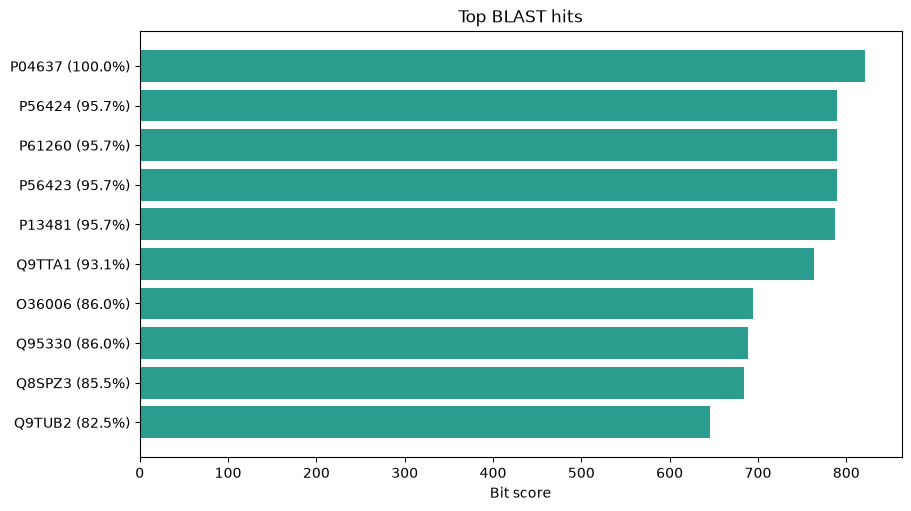

In [ ]:
top = hits_df.head(10).iloc[::-1]                   
labels = ["%s (%s%%)" % (acc, pct) for acc, pct in zip(top["accession"], top["identity_%"])]

plt.figure(figsize=(9, 5), constrained_layout=True)
plt.barh(labels, top["bit_score"], color="#2a9d8f")
plt.xlabel("Bit score")
plt.title("Top BLAST hits")
plt.show()

In [ ]:
def _wrap_alignment(hsp, width=60):
  
    query = str(hsp.query)
    subject = str(hsp.sbjct)
    match = str(hsp.match)
    if len(match) != len(query):
        match = "".join(q if q == s else " " for q, s in zip(query, subject))

    q_pos, s_pos = hsp.query_start, hsp.sbjct_start
    for start in range(0, len(query), width):
        q_chunk = query[start:start + width]
        s_chunk = subject[start:start + width]
        m_chunk = match[start:start + width]
        q_end = q_pos + len(q_chunk.replace("-", "")) - 1  
        s_end = s_pos + len(s_chunk.replace("-", "")) - 1
        yield ("Query  %5d  %s  %d" % (q_pos, q_chunk, q_end),
               " " * 13 + m_chunk,
               "Sbjct  %5d  %s  %d" % (s_pos, s_chunk, s_end))
        q_pos, s_pos = q_end + 1, s_end + 1


def generate_full_report(xml_file, report_name=None):
    blast_record = _load_blast_record(xml_file)

    if report_name is None:
        report_name = os.path.splitext(os.path.basename(xml_file))[0]
    txt_file = os.path.join(OUTPUT_DIR, report_name + "_full_report.txt")
    csv_file = os.path.join(OUTPUT_DIR, report_name + "_hits.csv")

    lines = [
        "=" * 78,
        "BLAST ANALYSIS - FULL REPORT",
        "Generated : %s" % datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Program   : %s" % blast_record.application.upper(),
        "Database  : %s" % blast_record.database,
        "Query     : %s" % blast_record.query,
        "Query len : %s residues" % blast_record.query_length,
        "=" * 78,
        "",
    ]
    csv_rows = []

    for i, alignment in enumerate(blast_record.alignments, 1):
        for j, hsp in enumerate(alignment.hsps, 1):
            positives = hsp.positives if hsp.positives is not None else hsp.identities
            identity_pct = 100 * hsp.identities / hsp.align_length
            similarity_pct = 100 * positives / hsp.align_length

            lines += [
                "-" * 78,
                "HIT %d   (alignment %d/%d for this hit)" % (i, j, len(alignment.hsps)),
                "  Subject    : %s" % alignment.title,
                "  Length     : %s" % alignment.length,
                "  Score      : %s   (bit score: %.1f)" % (hsp.score, hsp.bits),
                "  E-value    : %g" % hsp.expect,
                "  Identities : %d/%d (%.1f %%)" % (hsp.identities, hsp.align_length, identity_pct),
                "  Positives  : %d/%d (%.1f %%)  [conservative substitutions included]" % (positives, hsp.align_length, similarity_pct),
                "  Gaps       : %d/%d" % (hsp.gaps, hsp.align_length),
                "",
            ]
            for triple in _wrap_alignment(hsp):
                lines += list(triple)
            lines.append("")

            csv_rows.append({
                "hit_no": i,
                "accession": alignment.accession,
                "hit_title": alignment.title.split(" >")[0],
                "score": hsp.score,
                "bit_score": round(hsp.bits, 1),
                "e_value": hsp.expect,
                "identity_%": round(identity_pct, 2),
                "similarity_%": round(similarity_pct, 2),
                "gaps": hsp.gaps,
                "align_len": hsp.align_length,
            })

    with open(txt_file, "w") as f:
        f.write("\n".join(lines))
    pd.DataFrame(csv_rows).to_csv(csv_file, index=False)

    return txt_file, csv_file


In [ ]:
txt_file, csv_file = generate_full_report(xml_file, report_name="TP53_blastp_swissprot")

# report
with open(txt_file) as f:
    preview = f.read().splitlines()

(EBI report flavour detected — normalising to NCBI record layout)
Full text report -> blast_results/TP53_blastp_swissprot_full_report.txt  (38.9 KB)
CSV hit table    -> blast_results/TP53_blastp_swissprot_hits.csv  (20 alignments)


/usr/local/python/3.14.2/lib/python3.14/site-packages/Bio/Blast/NCBIWWW.py:275: BiopythonWarning: BLAST request A8G7YXB4014 is taking longer than 10 minutes, consider re-issuing it
  warnings.warn(
